# 04 · El barrido: ¿aportan algo los datos sintéticos?

## El diseño experimental


#### ***(Esta es la gráfica que que dijiste que era imprescindible: el error del modelo downstream frente al número de datos reales, con una curva por cantidad de datos sintéticos, y un panel por generador, así que aquí es donde ponemos a prueba la implementación de los datos sintéticos)***


Una celda del experimento es una tupla `(semilla, generador, n_real, n_synth)` y se ejecuta así:

1. se submuestrean `n_real` ventanas reales de train, **manteniendo la proporción de clases**;
2. se añaden `n_synth` ventanas sintéticas **de la clase minoritaria**, todas con etiqueta 1;
3. se entrena la arquitectura congelada **desde cero**;
4. se ajusta el umbral de decisión en el conjunto de validación **real** y se evalúa en el de test **real**.

La rejilla es `n_real ∈ {500, 1000, 2000, 4000, todos}` × `n_synth ∈ {0, 250, 500, 1000, 2000}` × 7 generadores ×
3 semillas, unas **450 celdas**.

## Los invariantes que hacen que la comparación tenga sentido

- **La arquitectura no cambia nunca.** Es el instrumento de medida.
- **Validación y test son 100% reales en todas las celdas.** No entra ni una ventana sintética.
- **Los generadores se ajustan una vez por semilla** con las ventanas minoritarias de train, y de cada uno se extrae
  un único *pool* de 2000 muestras del que los `n_synth` menores son prefijos. Así las curvas no se contaminan con
  ruido de muestreo entre puntos de la rejilla (es lo que hace el profesor con `X_train_aux_synth[0:1000]`).
- **`n_synth = 0` no depende del generador**, así que se calcula una vez por `(semilla, n_real)` y se comparte.
- **Cada celda guarda su curva de loss en disco**, para que todo número reportado tenga detrás una prueba de
  convergencia.

## Por qué submuestreamos al azar y no cogemos los datos más recientes

Coger las últimas `n_real` ventanas sería más realista ("un analista con poco histórico"), pero cambiaría **el
periodo histórico a la vez que el tamaño de muestra**: una caída del error podría ser escasez o podría ser otro
régimen de mercado. Submuestrear sobre todo el bloque de entrenamiento aísla el efecto que queremos medir.




#### ***(Como un elemento importante que tenemos que mencionar es que al añadir solo minoritarios, la proporción de clases del entrenamiento se distorsiona: con reales de 500 y el número de sintéticos es de 2000, el 82% del conjunto es clase positiva. Las métricas de ranking como el PR-AUC son robustas a eso, lo que es una razón más para haberla elegido como métrica principal. Pero conviene tenerlo presente al mirar la precisión y el recall, que sí dependen del umbral.)***



In [3]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

In [4]:
from src import sweep
from src.data import load_problem

split, _, _ = load_problem()
sweep.run_sweep(split)

  [seed 0] ruido           ajustado en   0.1s -> pool (2000, 60, 23)
  [seed 0] gaussiano       ajustado en   0.8s -> pool (2000, 60, 23)
  [seed 0] student_t       ajustado en   0.8s -> pool (2000, 60, 23)
  [seed 0] vae             ajustado en 612.4s -> pool (2000, 60, 23)
  [seed 0] gan             ajustado en 259.5s -> pool (2000, 60, 23)
  [seed 0] autoregresivo   ajustado en 1153.1s -> pool (2000, 60, 23)
  [seed 0] factor_mercado  ajustado en 481.0s -> pool (2000, 60, 23)
  [seed 0] r=  500 g=   0 sin_sinteticos   val_pr=0.737 test_pr=0.479 (23.6s)
  [seed 0] r=  500 g= 250 ruido            val_pr=0.721 test_pr=0.489 (26.0s)
  [seed 0] r=  500 g= 500 ruido            val_pr=0.738 test_pr=0.498 (29.1s)
  [seed 0] r=  500 g=1000 ruido            val_pr=0.740 test_pr=0.540 (34.1s)
  [seed 0] r=  500 g=2000 ruido            val_pr=0.734 test_pr=0.507 (46.9s)
  [seed 0] r=  500 g= 250 gaussiano        val_pr=0.730 test_pr=0.500 (26.8s)
  [seed 0] r=  500 g= 500 gaussiano        val_p

,seed,generator,n_real,n_synth,n_real_efectivo,n_train,tasa_positivos_train,epocas,segundos,val_pr_auc,val_roc_auc,val_f1,val_precision,val_recall,val_threshold,val_base_rate,val_lift,test_pr_auc,test_roc_auc,test_f1,test_precision,test_recall,test_threshold,test_base_rate,test_lift
0,0,sin_sinteticos,500.0,0,500,500,0.050000,100,23.6,0.737030,0.880193,0.685259,0.905263,0.551282,0.064845,0.132766,5.551348,0.478904,0.814806,0.430464,0.546218,0.355191,0.064845,0.077905,6.147238
1,0,ruido,500.0,250,500,750,0.366667,100,26.0,0.720556,0.864166,0.710938,0.910000,0.583333,0.651230,0.132766,5.427262,0.488592,0.801803,0.388235,0.420382,0.360656,0.651230,0.077905,6.271595
2,0,ruido,500.0,500,500,1000,0.525000,100,29.1,0.737975,0.857375,0.685259,0.905263,0.551282,0.733333,0.132766,5.558464,0.497646,0.818797,0.440129,0.539683,0.371585,0.733333,0.077905,6.387821
3,0,ruido,500.0,1000,500,1500,0.683333,100,34.1,0.740178,0.866204,0.705882,0.795181,0.634615,0.877709,0.132766,5.575057,0.539515,0.839671,0.473404,0.461140,0.486339,0.877709,0.077905,6.925248
4,0,ruido,500.0,2000,500,2500,0.810000,100,46.9,0.733594,0.854958,0.689243,0.910526,0.554487,0.962483,0.132766,5.525465,0.506583,0.827897,0.433657,0.531746,0.366120,0.962483,0.077905,6.502532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,2,autoregresivo,NaN,2000,11336,13336,0.192487,100,157.5,0.731736,0.862156,0.703008,0.850000,0.599359,0.113288,0.132766,5.511476,0.542393,0.843185,0.461538,0.464088,0.459016,0.113288,0.077905,6.962186
431,2,factor_mercado,NaN,250,11336,11586,0.070516,100,141.1,0.716878,0.875162,0.652344,0.835000,0.535256,0.247635,0.132766,5.399560,0.511848,0.811105,0.471380,0.614035,0.382514,0.247635,0.077905,6.570114
432,2,factor_mercado,NaN,500,11336,11836,0.090149,100,141.0,0.707440,0.859512,0.684211,0.827273,0.583333,0.143701,0.132766,5.328472,0.459472,0.775818,0.396341,0.448276,0.355191,0.143701,0.077905,5.897817
433,2,factor_mercado,NaN,1000,11336,12336,0.127027,100,151.0,0.710645,0.863153,0.678766,0.782427,0.599359,0.166657,0.132766,5.352617,0.464423,0.782697,0.382609,0.407407,0.360656,0.166657,0.077905,5.961370


In [5]:
from src import config, data, plots, sweep

resultados = sweep.load_results()
print(f"Celdas ejecutadas: {len(resultados)}")
print(f"Semillas: {sorted(resultados['seed'].unique())}")
print(f"n_real: {sorted(resultados['n_real'].dropna().unique())} (+ 'todos')")
print(f"n_synth: {sorted(resultados['n_synth'].unique())}")
print(f"Generadores: {sorted(resultados['generator'].unique())}")
print(f"\nTiempo total de cómputo: {resultados['segundos'].sum()/60:.0f} min")

Celdas ejecutadas: 435
Semillas: [np.int64(0), np.int64(1), np.int64(2)]
n_real: [np.float64(500.0), np.float64(1000.0), np.float64(2000.0), np.float64(4000.0)] (+ 'todos')
n_synth: [np.int64(0), np.int64(250), np.int64(500), np.int64(1000), np.int64(2000)]
Generadores: ['autoregresivo', 'factor_mercado', 'gan', 'gaussiano', 'ruido', 'sin_sinteticos', 'student_t', 'vae']

Tiempo total de cómputo: 496 min


## Comprobación de que el barrido hizo lo que dijimos

Antes de interpretar nada, verificamos los invariantes sobre la tabla de resultados: los tamaños de entrenamiento
son los esperados y la distorsión de la proporción de clases es la que anticipábamos.

In [6]:
chequeo = (resultados
    .assign(n_real=lambda d: d["n_real"].fillna(-1))
    .groupby(["n_real", "n_synth"])
    .agg(n_celdas=("test_pr_auc", "size"),
         n_train=("n_train", "mean"),
         tasa_pos_train=("tasa_positivos_train", "mean"),
         epocas=("epocas", "mean"))
    .round(3))
display(chequeo)

n_celdas  n_train  tasa_pos_train  epocas
n_real  n_synth                                           
-1.0    0               3  11336.0           0.050   100.0
        250            21  11586.0           0.071   100.0
        500            21  11836.0           0.090   100.0
        1000           21  12336.0           0.127   100.0
        2000           21  13336.0           0.192   100.0
 500.0  0               3    500.0           0.050   100.0
        250            21    750.0           0.367   100.0
        500            21   1000.0           0.525   100.0
        1000           21   1500.0           0.683   100.0
        2000           21   2500.0           0.810   100.0
 1000.0 0               3   1000.0           0.050   100.0
        250            21   1250.0           0.240   100.0
        500            21   1500.0           0.367   100.0
        1000           21   2000.0           0.525   100.0
        2000           21   3000.0           0.683   100.0
 2000.0 0               3   2000.0           0.050   100.0
        250            21   2250.0           0.156   100.0
        500            21   2500.0           0.240   100.0
        1000           21   3000.0           0.367   100.0
        2000           21   4000.0           0.525   100.0
 4000.0 0               3   4000.0           0.050   100.0
        250            21   4250.0           0.106   100.0
        500            21   4500.0           0.156   100.0
        1000           21   5000.0           0.240   100.0
        2000           21   6000.0           0.367   100.0

## TSTR: sólo con sintéticos

Antes de mirar la mezcla, la prueba más agresiva es entrenar **únicamente con sintéticos** y evaluar contra
reales. Es la métrica canónica en la literatura de series temporales sintéticas (*train on synthetic, test on
real*, TSTR): si un generador captura lo que importa para la tarea, su TSTR se acerca al techo de "todo real"; si
no lo captura, cae en picado. Reutilizamos los pools sintéticos ya ajustados (uno por semilla y generador) y
entrenamos la CNN con 2000 minoritarios sintéticos más 2000 mayoritarios construidos escalando esos mismos
sintéticos para que su vol de cartera caiga por debajo del umbral. No entra ni una ventana real en el train.

In [ ]:
from src import experiments, data, plots

split, _, _ = data.load_problem()
tstr = experiments.tstr_table(split, seeds=(0, 1, 2), n_synth=2000)
resumen = (
    tstr.groupby("generator")[["val_pr_auc", "test_pr_auc"]]
        .agg(["mean", "std"])
        .round(3)
)
# Reordenar en el mismo orden que el resto del notebook
resumen = resumen.reindex([g for g in plots.GEN_ORDER if g in resumen.index])
display(resumen)

  [seed 0] ruido           ajustado en   0.1s -> pool (2000, 60, 23)
  [seed 0] gaussiano       ajustado en   0.9s -> pool (2000, 60, 23)
  [seed 0] student_t       ajustado en   0.9s -> pool (2000, 60, 23)
  [seed 0] vae             ajustado en 525.3s -> pool (2000, 60, 23)
  [seed 0] gan             ajustado en 232.9s -> pool (2000, 60, 23)
  [seed 0] autoregresivo   ajustado en  73.4s -> pool (2000, 60, 23)
  [seed 0] factor_mercado  ajustado en 501.1s -> pool (2000, 60, 23)
  [seed 0] TSTR ruido            val_pr=0.547 test_pr=0.331
  [seed 0] TSTR gaussiano        val_pr=0.593 test_pr=0.291
  [seed 0] TSTR student_t        val_pr=0.721 test_pr=0.491
  [seed 0] TSTR vae              val_pr=0.598 test_pr=0.228
  [seed 0] TSTR gan              val_pr=0.532 test_pr=0.176
  [seed 0] TSTR autoregresivo    val_pr=0.462 test_pr=0.145
  [seed 0] TSTR factor_mercado   val_pr=0.621 test_pr=0.404
  [seed 1] ruido           ajustado en   0.1s -> pool (2000, 60, 23)
  [seed 1] gaussiano       a

val_pr_auc        test_pr_auc       
                     mean    std        mean    std
generator                                          
ruido               0.558  0.010       0.314  0.035
gaussiano           0.602  0.010       0.308  0.019
student_t           0.720  0.006       0.486  0.005
factor_mercado      0.624  0.010       0.403  0.004
vae                 0.492  0.188       0.222  0.064
gan                 0.492  0.127       0.203  0.070
autoregresivo       0.574  0.101       0.267  0.135

## La gráfica principal

Un panel por generador (los siete del notebook 03). En negro, la referencia: **sin sintéticos**. Las barras de
error son el error estándar sobre las 3 semillas.

Lo que hay que buscar, y que es lo que Valero anticipó en clase:

- con **pocos datos reales**, hueco entre las curvas de colores y la negra: ahí los sintéticos aportan;
- con **muchos datos reales**, las curvas se juntan o se cruzan: ya no hay nada que aportar, y añadir sintéticos
  puede incluso perjudicar;
- y los **generadores que reproducen la vol de cartera** (ruido y factor de mercado) marcando la referencia difícil
  de batir para los modelos sofisticados. Es una confirmación del argumento del notebook 03.

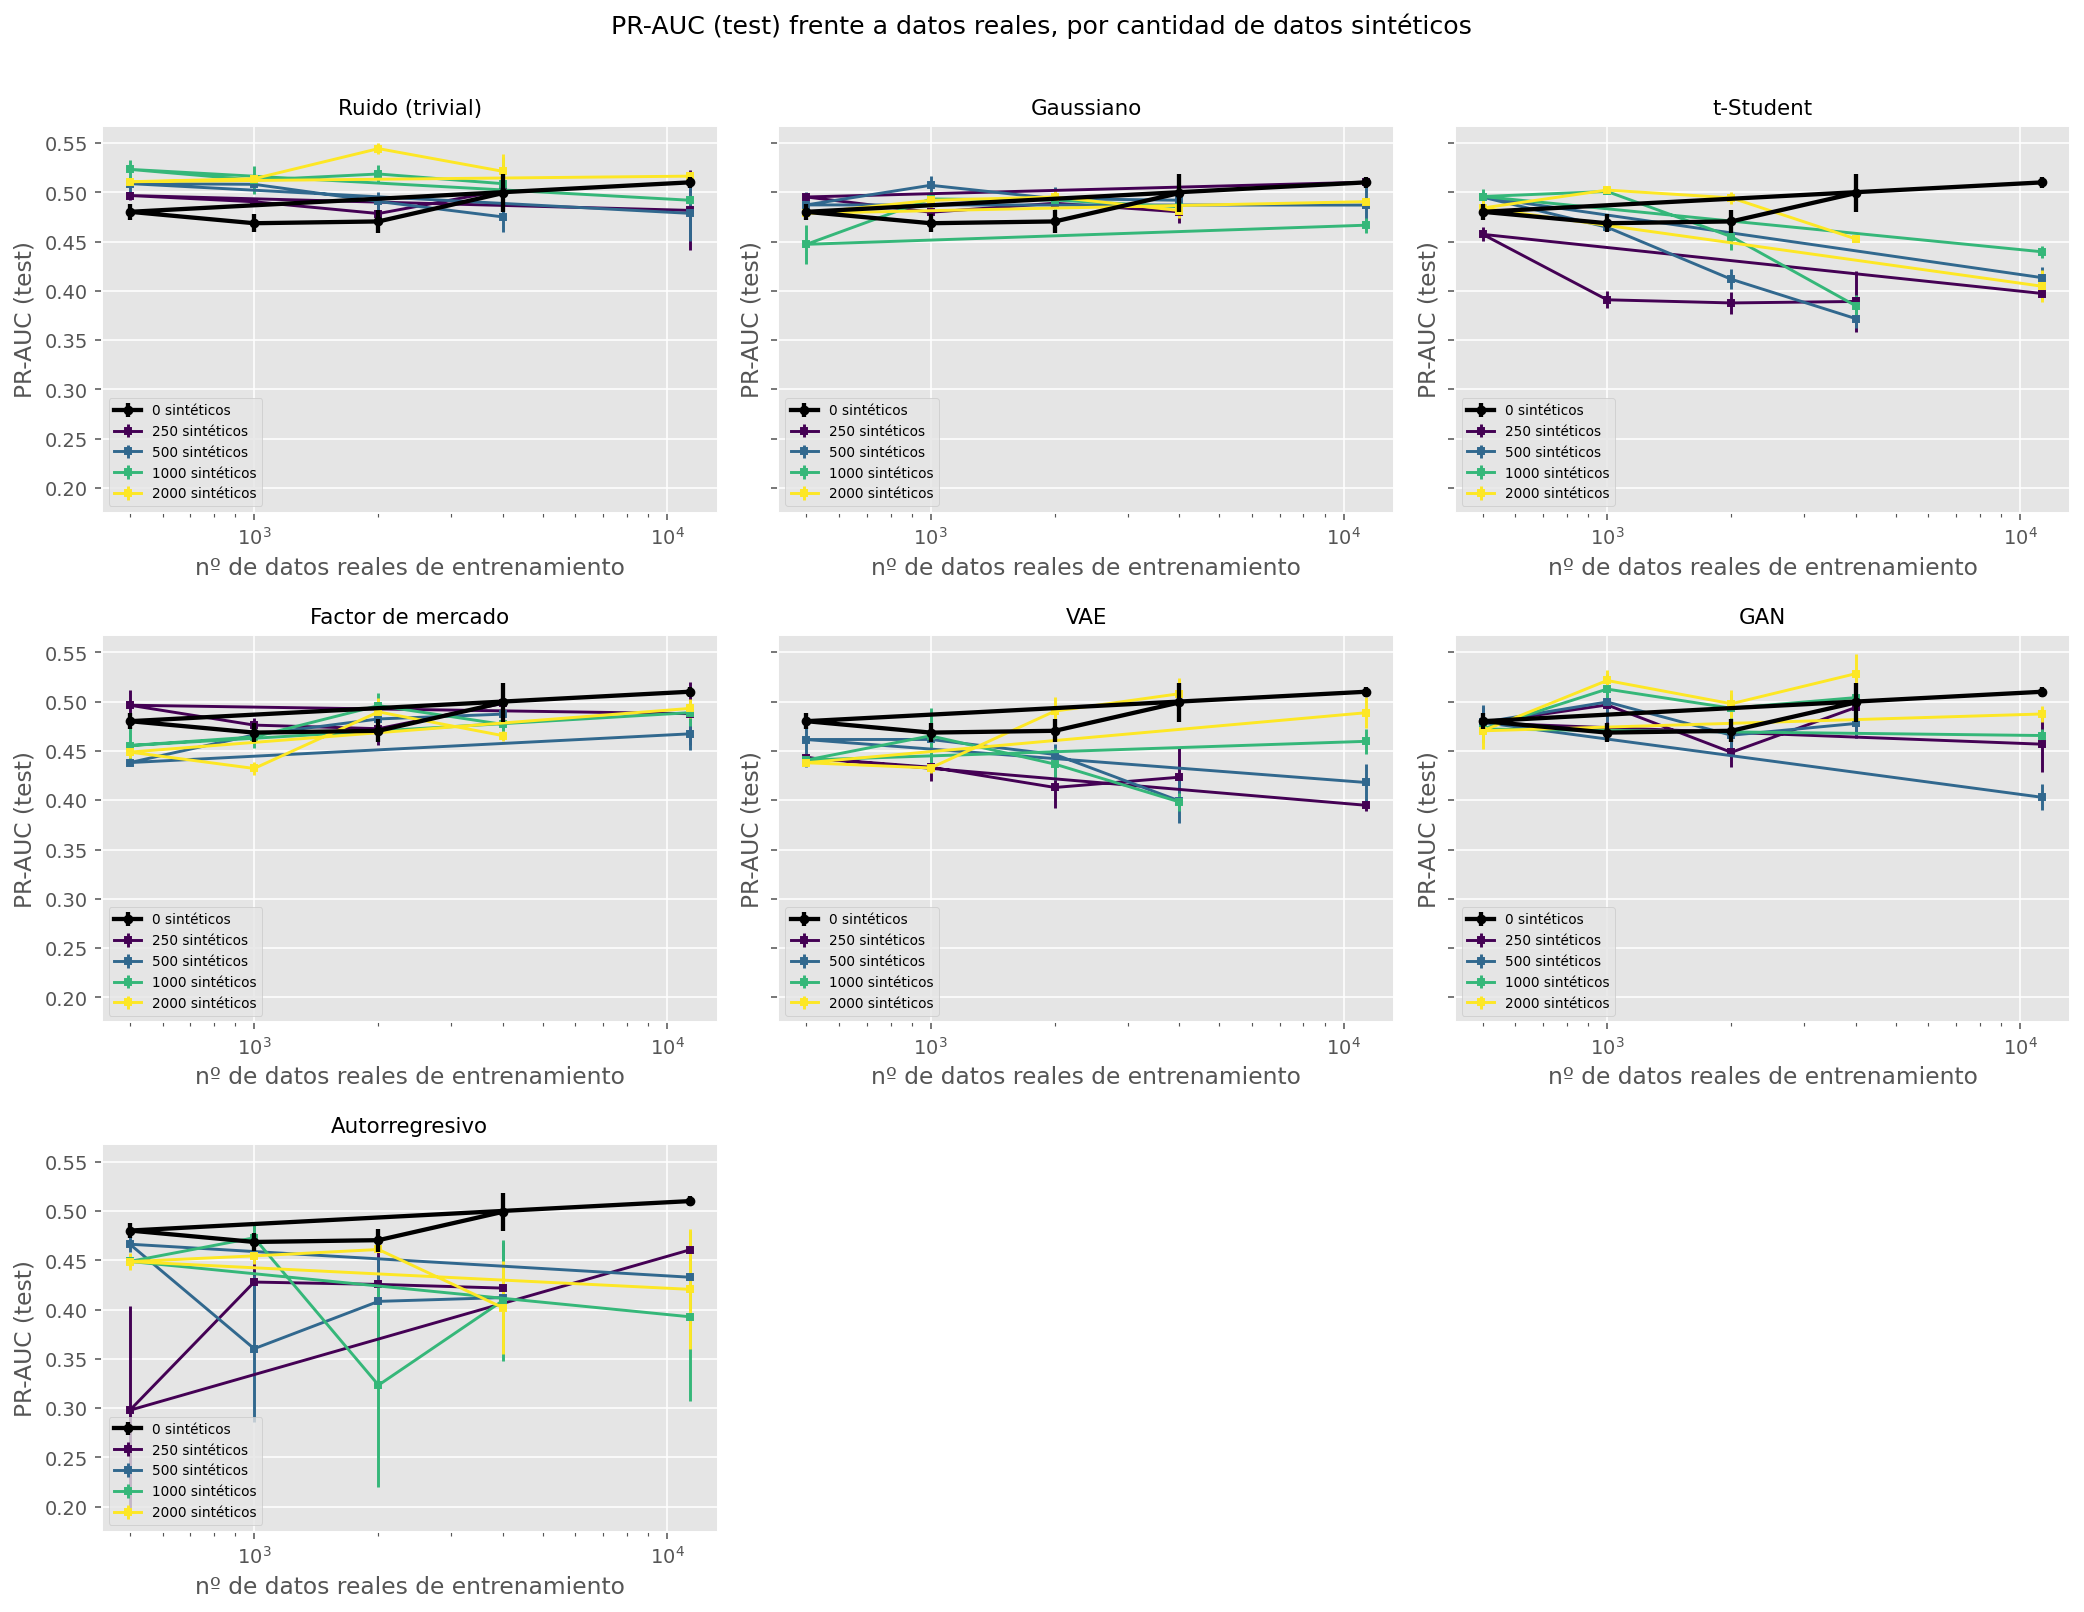

In [7]:
fig = plots.plot_sweep_per_generator(resultados, metric="test_pr_auc")
display(Image(str(fig)))

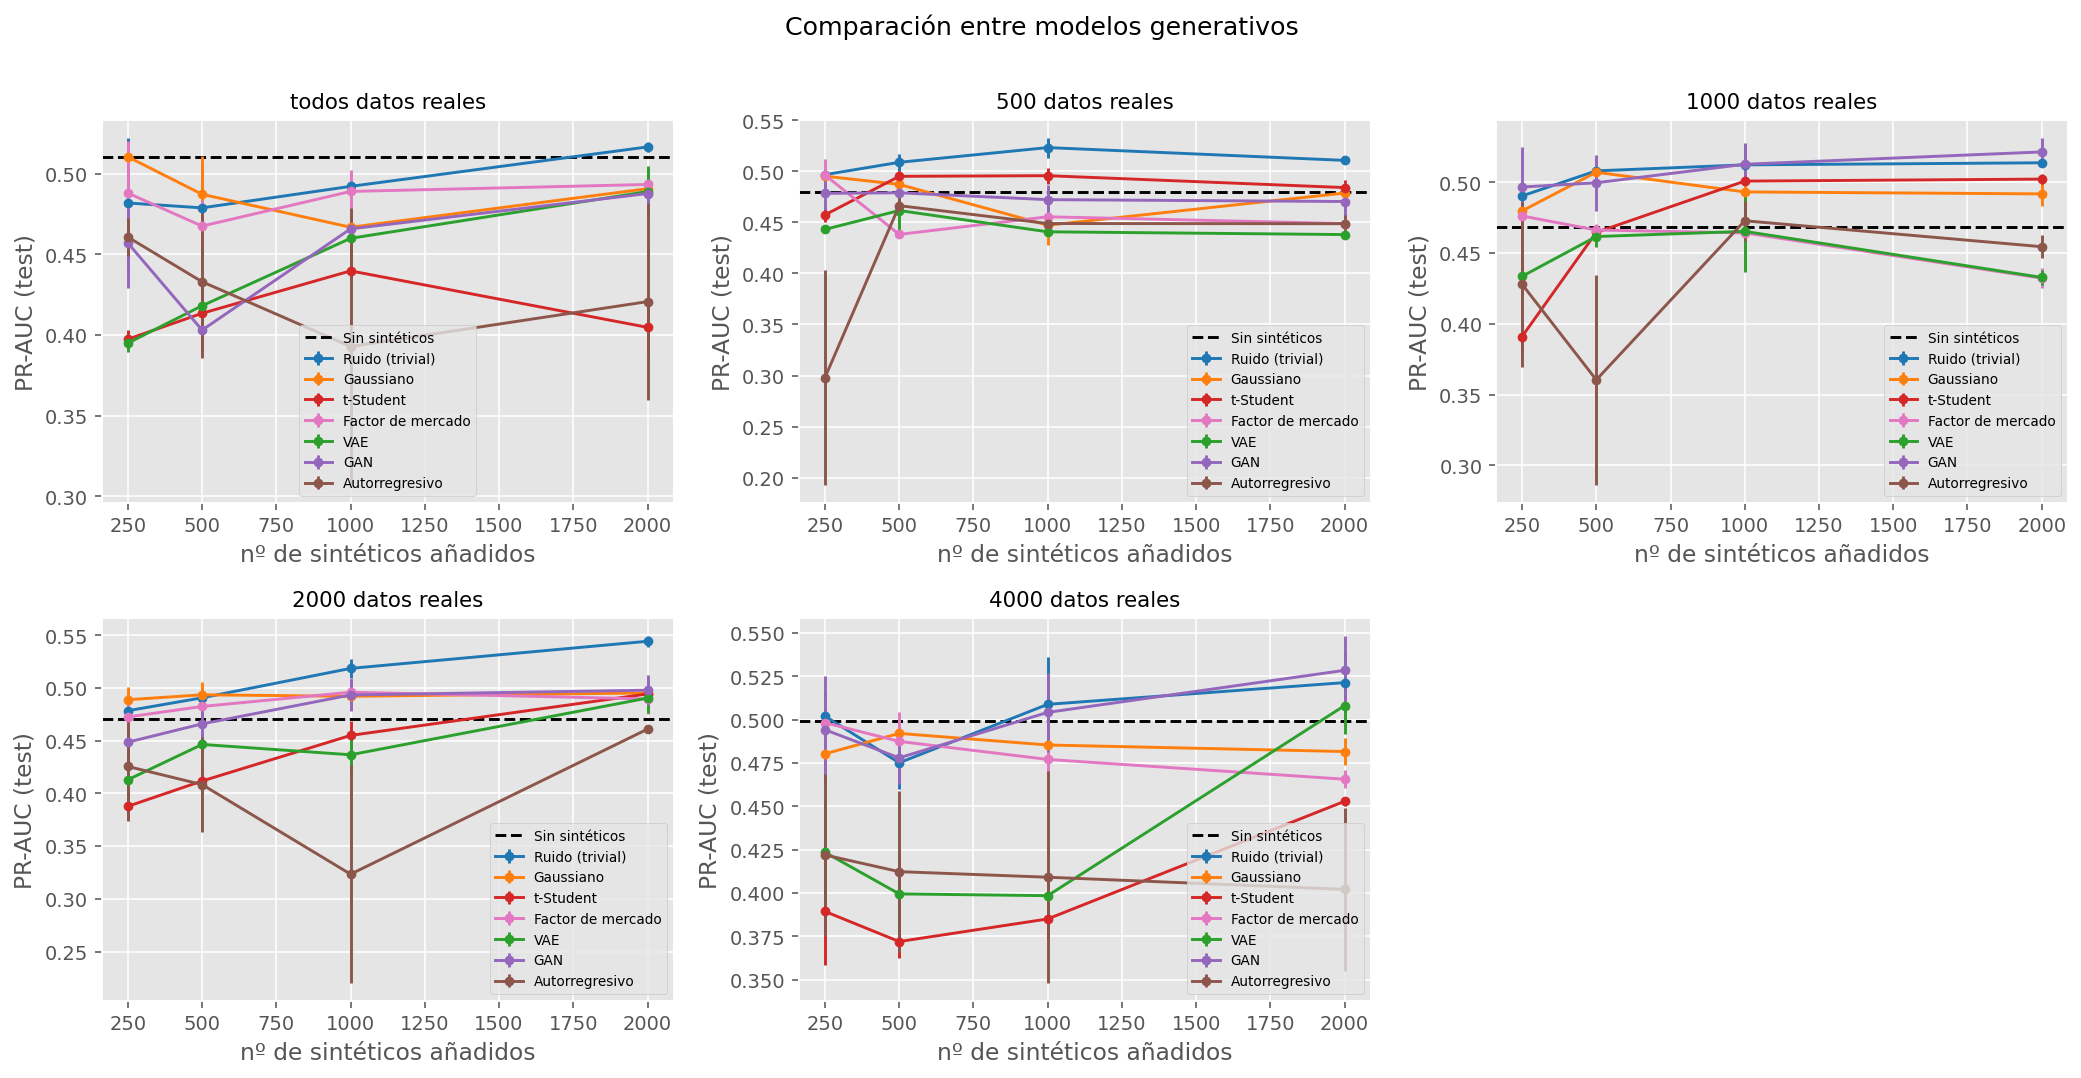

In [8]:
fig = plots.plot_sweep_generator_comparison(resultados, metric="test_pr_auc")
display(Image(str(fig)))

## La misma historia en números

Media sobre semillas del PR-AUC en test. La fila `sin_sinteticos` es la referencia de cada columna.

In [9]:
tabla = (resultados
    .assign(n_real=lambda d: d["n_real"].fillna(-1).astype(int))
    .pivot_table(index=["generator", "n_synth"], columns="n_real",
                 values="test_pr_auc", aggfunc="mean")
    .rename(columns=lambda c: "todos" if c == -1 else str(c)))
orden = [g for g in plots.GEN_ORDER if g in tabla.index.get_level_values(0)]
display(tabla.loc[orden].round(3))

n_real                  todos    500   1000   2000   4000
generator      n_synth                                   
sin_sinteticos 0        0.510  0.480  0.469  0.471  0.499
ruido          250      0.482  0.497  0.490  0.479  0.502
               500      0.479  0.509  0.508  0.491  0.475
               1000     0.492  0.523  0.512  0.519  0.509
               2000     0.516  0.511  0.514  0.544  0.521
gaussiano      250      0.510  0.495  0.480  0.489  0.480
               500      0.487  0.487  0.507  0.494  0.492
               1000     0.467  0.447  0.493  0.492  0.485
               2000     0.491  0.479  0.492  0.495  0.482
student_t      250      0.397  0.457  0.391  0.388  0.389
               500      0.413  0.495  0.465  0.412  0.372
               1000     0.440  0.496  0.501  0.455  0.385
               2000     0.405  0.484  0.502  0.494  0.453
factor_mercado 250      0.488  0.496  0.476  0.473  0.498
               500      0.467  0.438  0.466  0.483  0.487
               1000     0.489  0.456  0.464  0.496  0.477
               2000     0.493  0.449  0.432  0.490  0.466
vae            250      0.395  0.443  0.434  0.413  0.423
               500      0.418  0.462  0.462  0.447  0.399
               1000     0.460  0.441  0.465  0.437  0.398
               2000     0.489  0.438  0.433  0.491  0.508
gan            250      0.457  0.479  0.497  0.449  0.494
               500      0.403  0.479  0.500  0.466  0.478
               1000     0.466  0.472  0.513  0.493  0.504
               2000     0.488  0.470  0.522  0.498  0.528
autoregresivo  250      0.461  0.298  0.428  0.426  0.422
               500      0.433  0.466  0.360  0.408  0.412
               1000     0.393  0.449  0.473  0.323  0.409
               2000     0.421  0.449  0.455  0.461  0.402

## Ganancia relativa frente a no usar sintéticos

Para cada combinación de generador y cantidad de datos reales, la mejor ganancia relativa que consigue **alguna**
cantidad de sintéticos. En rojo, los casos en los que los datos sintéticos ayudaron.

Advertencia honesta de lectura: coger el mejor `n_synth` a posteriori es una forma de selección, así que estos
números son un **techo optimista** de lo que se conseguiría eligiendo `n_synth` a ciegas. Los tratamos como
"¿existe alguna cantidad de sintéticos que ayude?", no como una estimación sin sesgo de la mejora esperable.

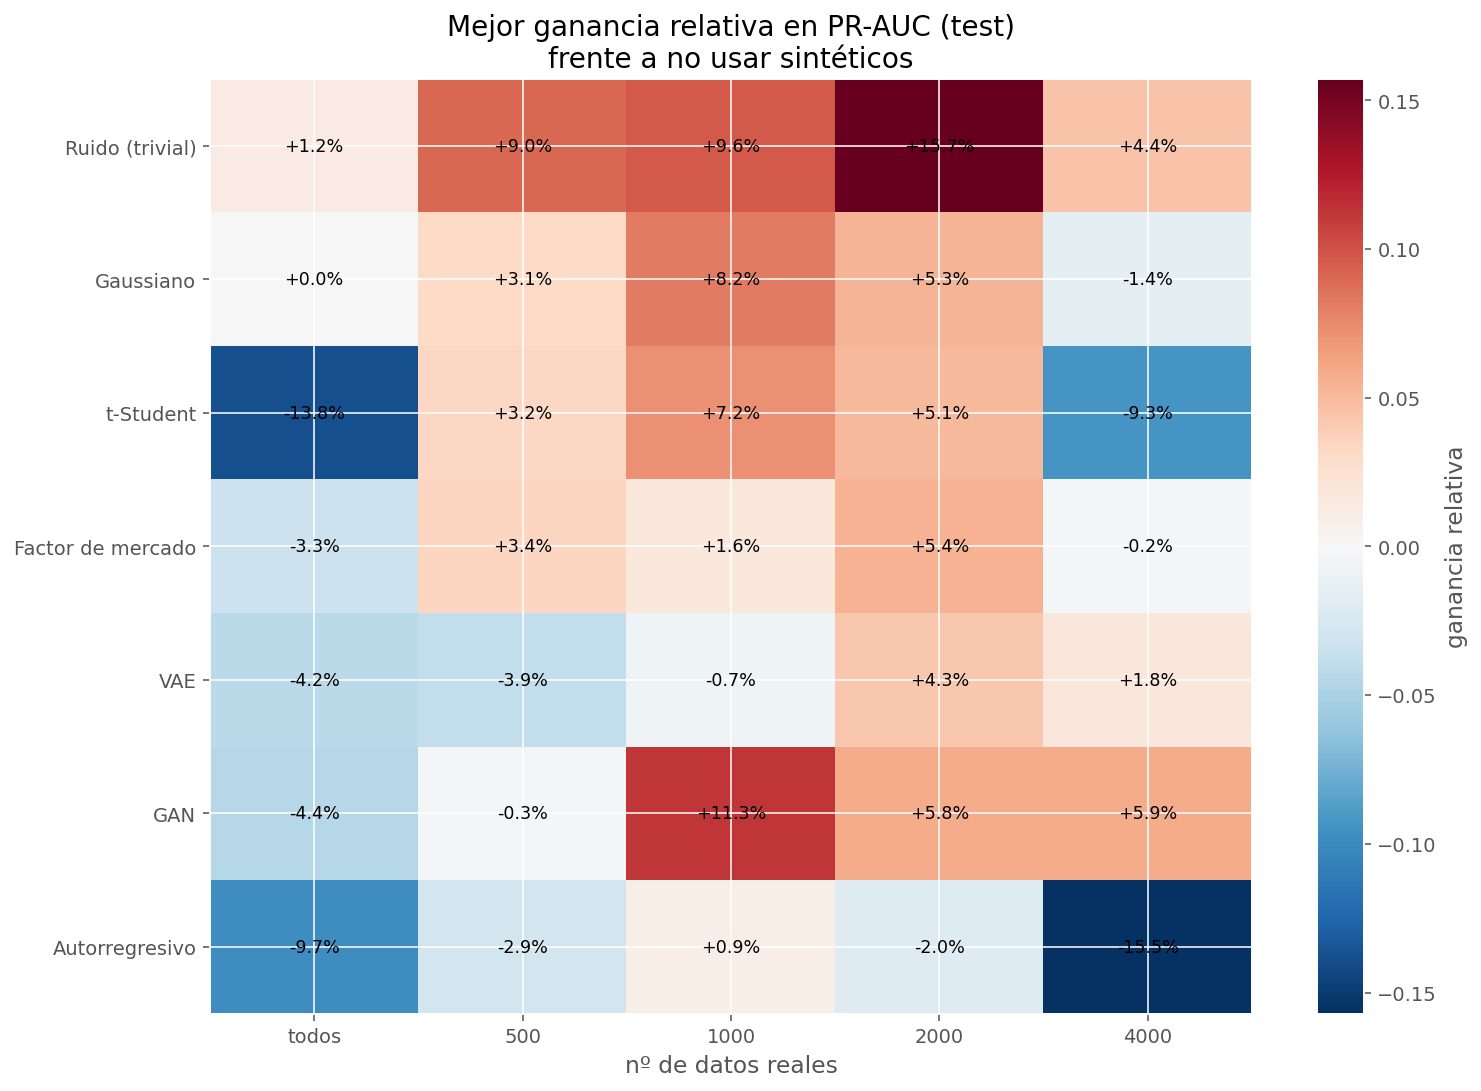

In [10]:
fig = plots.plot_gain_heatmap(resultados, metric="test_pr_auc")
display(Image(str(fig)))